In [3]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

# Single mode squeezing

Need damping to prevent parametric instability from exciting us far outside of the Hilbert space:

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

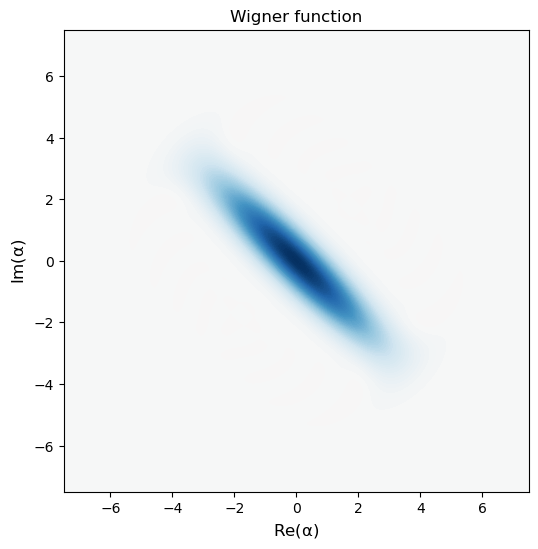

In [45]:
N = 20
a = destroy(N)
kappa = 1
eps = 0.23

H = eps*(a*a + a.dag()*a.dag())
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

# Single mode parametron

Damped:

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

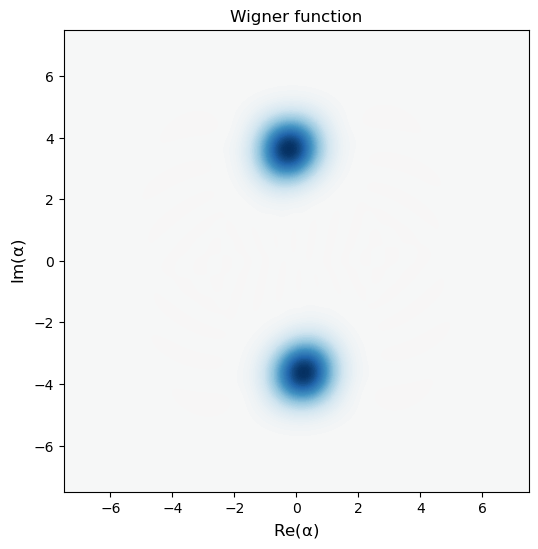

In [102]:
N = 20
a = destroy(N)
kappa = 1
eps = 2
K = 0.3

H = eps*(a*a + a.dag()*a.dag()) + K*(a.dag()*a.dag()*a*a)
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

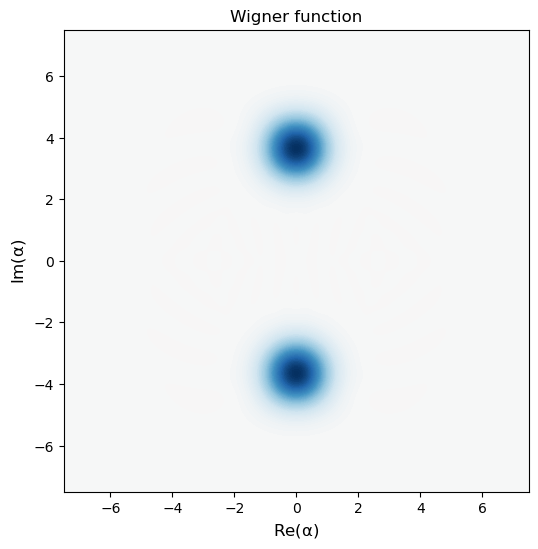

In [55]:
N = 20
a = destroy(N)
kappa = 0.000001 # for steady state, kappa cannot be zero
eps = 2
K = 0.3

H = eps*(a*a + a.dag()*a.dag()) + K*(a.dag()*a.dag()*a*a)
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

# Two mode squeezing

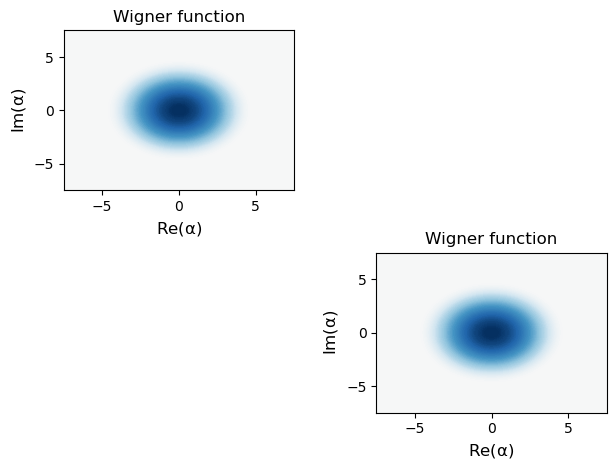

In [89]:
N = 10
a = tensor(destroy(N), identity(N))
b = tensor(identity(N), destroy(N))

kappa = 1
eps = 0.5

H = eps*(a*b + a.dag()*b.dag())
c_ops = [np.sqrt(kappa)*a, np.sqrt(kappa)*b]

res = steadystate(H, c_ops)
ax = plt.subplot(2,2,1)
plot_wigner(res.ptrace(0), ax=ax)
ax = plt.subplot(2,2,4)
plot_wigner(res.ptrace(1), ax=ax)
plt.tight_layout()

Seems there is no easy way to calculate cross wigner functions...:

https://groups.google.com/g/qutip/c/A5Cjq3PZcU8?pli=1

The other two quadrants of my plots will have to wait...

# Two Mode squeezing with one Kerr oscillator

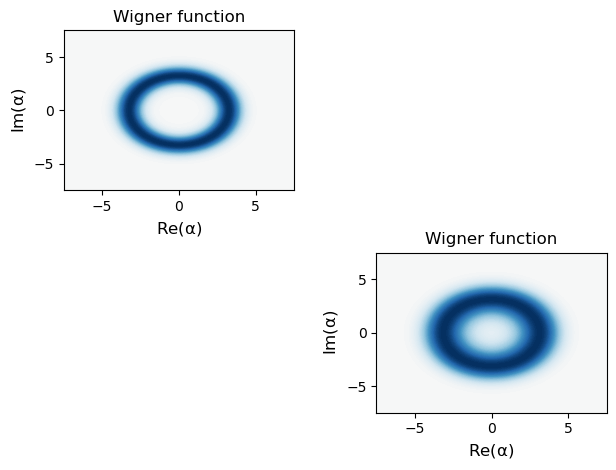

In [111]:
N = 20
a = tensor(destroy(N), identity(N))
b = tensor(identity(N), destroy(N))

kappa = .0001
eps = 1.5
K = 0.3

H = eps*(a*b + a.dag()*b.dag()) + K*a.dag()*a.dag()*a*a
c_ops = [np.sqrt(kappa)*a, np.sqrt(kappa)*b]

res = steadystate(H, c_ops)
ax = plt.subplot(2,2,1)
plot_wigner(res.ptrace(0), ax=ax)
ax = plt.subplot(2,2,4)
plot_wigner(res.ptrace(1), ax=ax)
plt.tight_layout()

First thing to note is that we now have a fininte steady state also in the absense of damping, suggesting parametron-like physics. My strong suspicion is that if we were able to calculate the "cross" Wigner functions, we would see well-defined parametron states. 

# Hacking a function to see the correlations

Maybe we can find a way to "hack" this. Can I find some expectation value that will let me visualise the correlations? What about some kind of expectation value of the amplitude of an operator with a certain angle? Let's try it our our single-mode squeezed state. 


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Wigner function'}, xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

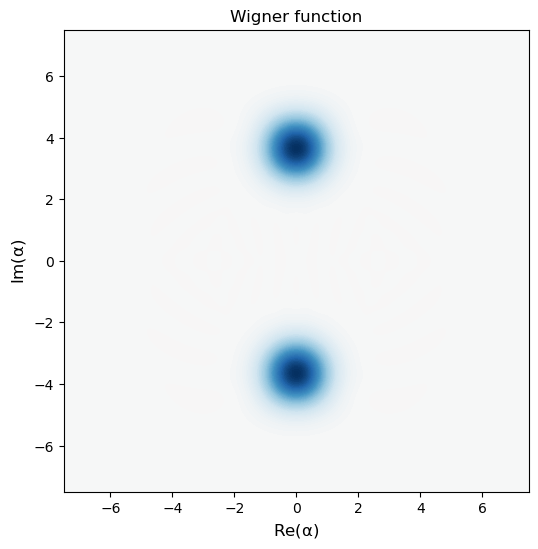

In [112]:
N = 20
a = destroy(N)
kappa = 0.000001 # for steady state, kappa cannot be zero
eps = 2
K = 0.3

H = eps*(a*a + a.dag()*a.dag()) + K*(a.dag()*a.dag()*a*a)
c_ops = [np.sqrt(kappa)*a]

res = steadystate(H, c_ops)
plot_wigner(res)

For example, the expectation value of x^2 of the above will be zero, but the expectation value of p^2 will be finite. 

In [116]:
theta = np.pi/2
obs = np.cos(theta)*(a.dag()+a) + 1j*np.sin(theta)*(a.dag()-a)
expect(res, obs*obs)

27.63600256706075

In [118]:
def calc_correlation(res, x, y):
    theta = np.linspace(0,np.pi,100)
    corr = []
    for t in np.linspace(0,np.pi,100):
        obs = np.cos(t)*x + 1j*np.sin(t)*y
        corr.append(expect(res, obs*obs))
    return(theta, corr)

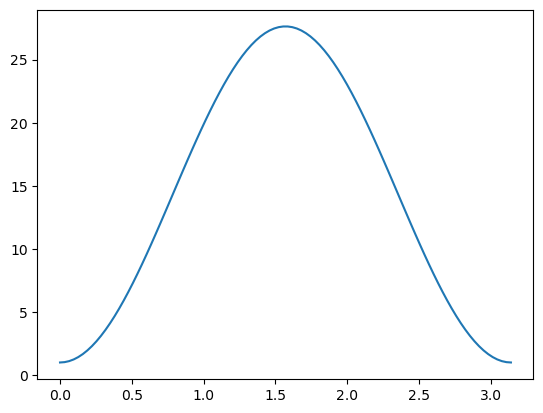

In [121]:
t,c = calc_correlation(res, a.dag()+a, a.dag()-a)
plt.plot(t,c)

In [141]:
def correlations_plot():
    plt.figure(figsize=(6,8))
    ax = plt.subplot(3,2,1)
    plot_wigner(res.ptrace(0), ax=ax)
    ax = plt.subplot(3,2,2)
    plot_wigner(res.ptrace(1), ax=ax)
    plt.subplot(3,2,3)
    t,c = calc_correlation(res, a.dag()+a, a.dag()-a)
    plt.plot(t,c)
    plt.subplot(3,2,4)
    t,c = calc_correlation(res, a.dag()+a, b.dag()-b)
    plt.plot(t,c)
    plt.subplot(3,2,5)
    t,c = calc_correlation(res, b.dag()+b, a.dag()-a)
    plt.plot(t,c)
    plt.subplot(3,2,6)
    t,c = calc_correlation(res, b.dag()+b, b.dag()-b)
    plt.plot(t,c)
    plt.tight_layout()

Start with something we understand: the TMS state

In [143]:
N = 10
a = tensor(destroy(N), identity(N))
b = tensor(identity(N), destroy(N))

kappa = 1
eps = 0.5

H = eps*(a*b + a.dag()*b.dag())
c_ops = [np.sqrt(kappa)*a, np.sqrt(kappa)*b]

res = steadystate(H, c_ops)

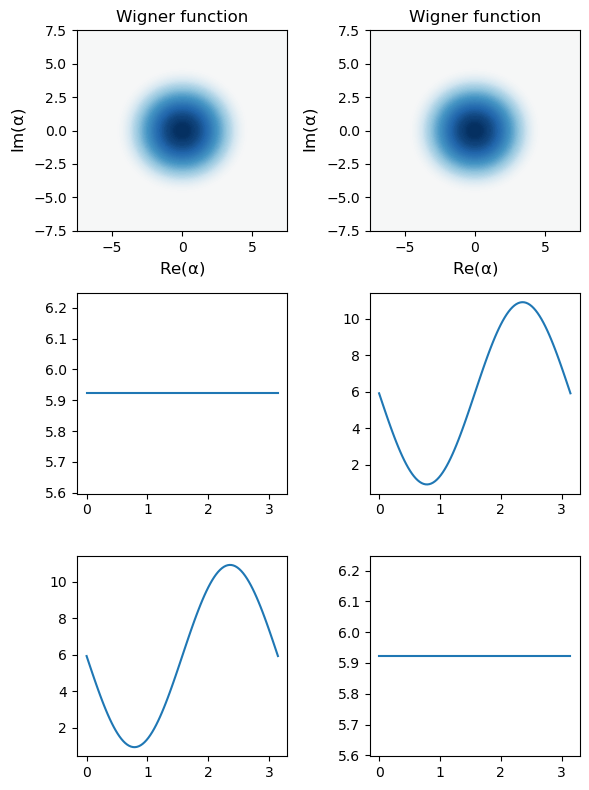

In [144]:
correlations_plot()

In [155]:
N = 20
a = tensor(destroy(N), identity(N))
b = tensor(identity(N), destroy(N))

kappa = 2
eps = 3
K = 1

H = eps*(a*b + a.dag()*b.dag()) + K*a.dag()*a.dag()*a*a
c_ops = [np.sqrt(kappa)*a, np.sqrt(kappa)*b]

res = steadystate(H, c_ops)

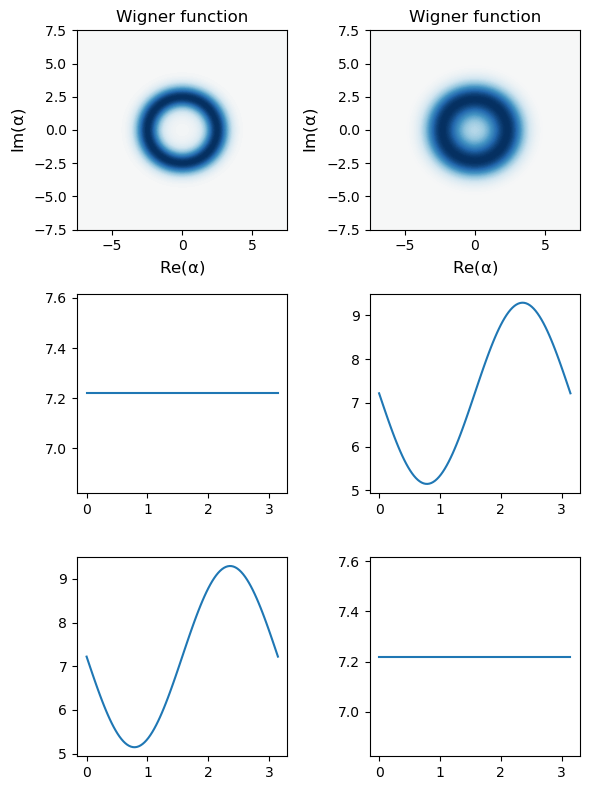

In [156]:
correlations_plot()

OK, this seems to be a set of parameters that give me strong correlations and also "rings":

```
kappa = 2
eps = 3
K = 1
```

I guess that if we could plot two-mode wigners here, we would see a "cross parametron"